In [ ]:
import numpy as np
import math
from datetime import datetime
import os
import subprocess #install to run bash lines from python
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import LogFormatterMathtext
import warnings
warnings.filterwarnings('ignore')

import sys
# sys.path.insert(1, '/home/rml000/Scripts/kin1d_functions_matlach/')
sys.path.insert(1, '/home/rml000/sitestore8/UQAM/Scripts/')
# sys.path.insert(1, '/home/rml000/sitestore8/UQAM/Event_20230405')
sys.path.append(os.path.expanduser('/home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4'))

%load_ext autoreload
%autoreload 1
%aimport kin1d_functions
%aimport get_manobs_soundings_pr_df



# Import manobs

In [2]:
df_manobs = pd.read_csv('df_all_events_tw_29juillet2026.csv')
df_manobs.loc[df_manobs.manobs_with_mix.isna(), 'manobs_with_mix'] = 'None'
df_manobs['rounded_time'] = pd.to_datetime(df_manobs['rounded_time'] ) 

# Select temperature, water vapor profile

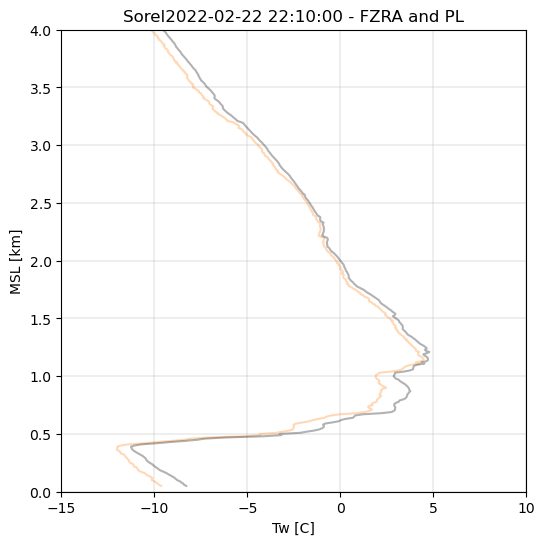

In [3]:
df_manobs = pd.read_csv('/home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/df_all_events_tw_18juin2026.csv')
df_manobs = df_manobs[df_manobs.Sounding==True]
row = df_manobs.loc[((df_manobs.IOP=='IOP5') & (df_manobs.site=='Sorel'))].iloc[0]
df_sounding = get_manobs_soundings_pr_df.plot_soundings_row(row,df_manobs)[:1000]

df_sounding.loc[:,'QV'] = np.array([kin1d_functions.qv_from_rh(df_sounding.iloc[i].RelHum/100.,df_sounding.iloc[i].Temp+273.15,df_sounding.iloc[i].Press*100.) for i in range(len(df_sounding.Temp)) ])
df_sounding.loc[:,'TD'] = np.array([kin1d_functions.dewpoint_from_rh(df_sounding.iloc[i].Temp+273.15,df_sounding.iloc[i].RelHum/100.,) for i in range(len(df_sounding.Temp)) ]) - 273.15

df_sounding = df_sounding.rename(columns={'Press':'PRES', 'height':'HGHT','Temp':'TEMP','TD':'DWPT','RelHum':'RELH'})
df_sounding = df_sounding.iloc[::3]

kin1d_functions.write_tprofile_file(df_sounding) 

# Simulation

In [ ]:

pr_list = [0.1,0.5,1.,2.,5.,10.]

pr_out_sim1 = [0.4375,1.4242000000000001,2.5761700000000003,4.993460000000001,13.10758,26.99209]

ds_list_pr = []

for i in range(len(pr_list)):
    pr_in_sim3 = ((pr_list[i]/pr_out_sim1[i])*pr_list[i])
    sfcprec, ncQ, ncN, nc8, nc9 = kin1d_functions.run_with_prof(pr_in_sim3, qgtop_ratio=0,input_dict_mod={'liqFrac':'.false.','n_iceCat':2,'dt_p3':1.,'ttotmin':150},all_drop_same_size=False)
    
    sfcprec.index.name = "time"
    ds_sfcprec = sfcprec.to_xarray()
    ds_all_pr = xr.merge([ds_sfcprec, ncQ, ncN, nc8, nc9],compat='override')
    
    ds_list_pr.append(ds_all_pr)


make: Entering directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep'
rm -f *.o *.mod fort.* execld out_p3.dat out* sfcprec.dat
make: Leaving directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep'
make: Entering directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep'
rm -f input_kinematic_model.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o input_kinematic_model.o input_kinematic_model.f90
rm -f microphy_p3.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o microphy_p3.o microphy_p3.f90
rm -f routinesCld1d.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o routinesCld1d.o routinesCld1d.f90
rm -f cld1d.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o cld1d.o cld1d.f90


cld1d.f90:851:16:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                1
cld1d.f90:851:33:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                                 1
cld1d.f90:851:50:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                                                  1
cld1d.f90:857:16:

  857 |         Ni1(1,k,3),Bg1(1,k,3)*10**8
      |                1
cld1d.f90:857:27:

  857 |         Ni1(1,k,3),Bg1(1,k,3)*10**8
      |                           1
cld1d.f90:866:16:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                1
cld1d.f90:866:33:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                                 1
cld1d.f90:866:50:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                                                  1
cld1d.f90:867:16:

  867 |         Qg1(

rm -f execld.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o execld.o execld.f90
rm -f execld
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g   -o execld execld.o input_kinematic_model.o microphy_p3.o routinesCld1d.o   cld1d.o 
rm execld.o
make: Leaving directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep'
Compiling../home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep/
Running../home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep/

 ** Remember to use compiler debug options for testing new code (modfify Makefile appropriately) **


  P3 microphysics: v5.5.1
    P3_INIT (reading/creating lookup tables)
      Reading table 1 [6.9-2momI] ...
      Reading table 2 [v6.2] ...
      Generating table for rain parameters ...
    P3_INIT DONE.

 Starting mai

cld1d.f90:851:16:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                1
cld1d.f90:851:33:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                                 1
cld1d.f90:851:50:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                                                  1
cld1d.f90:857:16:

  857 |         Ni1(1,k,3),Bg1(1,k,3)*10**8
      |                1
cld1d.f90:857:27:

  857 |         Ni1(1,k,3),Bg1(1,k,3)*10**8
      |                           1
cld1d.f90:866:16:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                1
cld1d.f90:866:33:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                                 1
cld1d.f90:866:50:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                                                  1
cld1d.f90:867:16:

  867 |         Qg1(

rm -f execld.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o execld.o execld.f90
rm -f execld
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g   -o execld execld.o input_kinematic_model.o microphy_p3.o routinesCld1d.o   cld1d.o 
rm execld.o
make: Leaving directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep'
Compiling../home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep/
Running../home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep/

 ** Remember to use compiler debug options for testing new code (modfify Makefile appropriately) **


  P3 microphysics: v5.5.1
    P3_INIT (reading/creating lookup tables)
      Reading table 1 [6.9-2momI] ...
      Reading table 2 [v6.2] ...
      Generating table for rain parameters ...
    P3_INIT DONE.

 Starting mai

...

rm -f execld.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o execld.o execld.f90
rm -f execld
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g   -o execld execld.o input_kinematic_model.o microphy_p3.o routinesCld1d.o   cld1d.o 
rm execld.o
make: Leaving directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep'
Compiling../home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep/
Running../home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep/

 ** Remember to use compiler debug options for testing new code (modfify Makefile appropriately) **


  P3 microphysics: v5.5.1
    P3_INIT (reading/creating lookup tables)
      Reading table 1 [6.9-2momI] ...
      Reading table 2 [v6.2] ...
      Generating table for rain parameters ...
    P3_INIT DONE.

 Starting mai

cld1d.f90:851:16:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                1
cld1d.f90:851:33:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                                 1
cld1d.f90:851:50:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                                                  1
cld1d.f90:857:16:

  857 |         Ni1(1,k,3),Bg1(1,k,3)*10**8
      |                1
cld1d.f90:857:27:

  857 |         Ni1(1,k,3),Bg1(1,k,3)*10**8
      |                           1
cld1d.f90:866:16:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                1
cld1d.f90:866:33:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                                 1
cld1d.f90:866:50:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                                                  1
cld1d.f90:867:16:

  867 |         Qg1(

rm -f execld.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o execld.o execld.f90
rm -f execld
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g   -o execld execld.o input_kinematic_model.o microphy_p3.o routinesCld1d.o   cld1d.o 
rm execld.o
make: Leaving directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep'
Compiling../home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep/
Running../home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep/

 ** Remember to use compiler debug options for testing new code (modfify Makefile appropriately) **


  P3 microphysics: v5.5.1
    P3_INIT (reading/creating lookup tables)
      Reading table 1 [6.9-2momI] ...
      Reading table 2 [v6.2] ...
      Generating table for rain parameters ...
    P3_INIT DONE.

 Starting mai

cld1d.f90:851:16:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                1
cld1d.f90:851:33:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                                 1
cld1d.f90:851:50:

  851 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                                                  1
cld1d.f90:857:16:

  857 |         Ni1(1,k,3),Bg1(1,k,3)*10**8
      |                1
cld1d.f90:857:27:

  857 |         Ni1(1,k,3),Bg1(1,k,3)*10**8
      |                           1
cld1d.f90:866:16:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                1
cld1d.f90:866:33:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                                 1
cld1d.f90:866:50:

  866 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                                                  1
cld1d.f90:867:16:

  867 |         Qg1(

rm -f execld.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o execld.o execld.f90
rm -f execld
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g   -o execld execld.o input_kinematic_model.o microphy_p3.o routinesCld1d.o   cld1d.o 
rm execld.o
make: Leaving directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep'
Compiling../home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep/
Running../home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/simu1d/src_sip-ffd-mod-notempdep/

 ** Remember to use compiler debug options for testing new code (modfify Makefile appropriately) **


  P3 microphysics: v5.5.1
    P3_INIT (reading/creating lookup tables)
      Reading table 1 [6.9-2momI] ...
      Reading table 2 [v6.2] ...
      Generating table for rain parameters ...
    P3_INIT DONE.

 Starting mai

In [44]:
import os

os.makedirs("outputs_sensitivity_sims", exist_ok=True)

for i, ds in enumerate(ds_list_pr):
    ds.to_netcdf(f"outputs_sensitivity_sims/ds_pr_{pr_list[i]}.nc")
    

# Figures

In [5]:
# Load simulations

import os
os.makedirs("outputs_sensitivity_sims", exist_ok=True)
ds_list_pr = []
pr_list = [0.1,0.5,1.,2.,5.,10.]
for i, ds in enumerate(pr_list):
    ds = xr.open_dataset(f"outputs_sensitivity_sims/ds_pr_{pr_list[i]}.nc")
    ds_list_pr.append(ds)
    

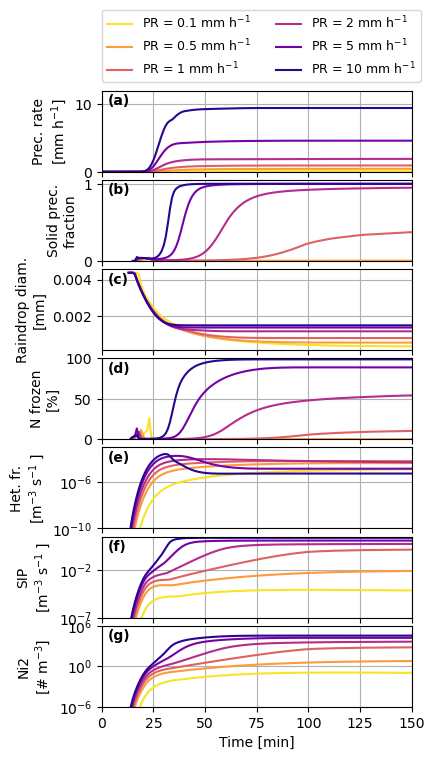

In [6]:
fig,ax = plt.subplots(7,1,figsize=(4, 8))

# colors = plt.cm.tab10(np.linspace(0, 1, len(ds_list_pr)))
# colors = plt.cm.turbo(np.linspace(0.1, 0.9, 6))
colors = plt.cm.plasma_r(np.linspace(0.05, 0.95, 6))
i=0
for sfcprec in ds_list_pr:
    ax[0].plot(sfcprec.time/60., (sfcprec.prt_liq+sfcprec.prt_sol), linestyle='-', color=colors[i])
    i=i+1

ax[0].set_xlim([0,150])
ax[0].set_ylim([0,12])
ax[0].set_xlabel('')
ax[0].set_ylabel('Prec. rate\n'+r'[mm h$^{-1}$]')
ax[0].grid('on')

i=0
for sfcprec in ds_list_pr:
    ax[1].plot(sfcprec.time/60., (sfcprec.prt_sol/(sfcprec.prt_liq+sfcprec.prt_sol)), linestyle='-', color=colors[i])
    i=i+1

ax[1].set_xlim([0,150])
ax[1].set_ylim([0,1.05])
ax[1].set_xlabel('')
ax[1].set_ylabel('Solid prec.\nfraction')
ax[1].grid('on')

for i in range(len(ds_list_pr)):
    ds_all = ds_list_pr[i]
    drcol = ((ds_all.qrcol*6)/(ds_all.nrcol*900.*np.pi))**(1./3.)
    dr = ((ds_all.Qfluxr*6)/(ds_all.Nfluxr*1000.*np.pi))**(1./3.)
    ax[2].plot(ds_all.time/60., dr.where(ds_all.Qfluxr>1e-14).sel(level=80), label=f'PR = {pr_list[i]:g} mm h$^{{-1}}$', linestyle='-', color=colors[i])
ax[2].grid('on')
ax[2].set_ylabel('Raindrop diam.\n[mm]')
ax[2].set_xlabel('')
ax[2].set_xlim([0,150])
ax[2].legend(loc='upper left', bbox_to_anchor=(0., 4.2), borderaxespad=0.0, fontsize=9,ncol=2)
    # (ds_all.Nfluxi1/ds_all.Nfluxr).sel(level=102).plot(label='Nfluxi1/Nfluxr',marker='+')


for i in range(len(ds_list_pr)):
    ds_all = ds_list_pr[i]
    ax[3].plot(ds_all.time/60., 100*(ds_all.Nfluxi1/(ds_all.Nfluxr+ds_all.Nfluxi1)).where(ds_all.Qfluxr>1e-14).sel(level=102),
               label=f' pr={pr_list[i]}', linestyle='-', color=colors[i])
# ax[3].set_yscale('log')
ax[3].grid('on')
ax[3].set_ylabel('N frozen\n[%]')
ax[3].set_xlabel('')
ax[3].set_xlim([0,150])
ax[3].set_ylim([0,100])


for i in range(len(ds_list_pr)):
    ds_all = ds_list_pr[i]
    ax[4].plot(ds_all.time/60., (ds_all['nrheti']*ds_all['rho']).sel(level=slice(90,102)).mean('level'),
               label=f'Het. fr. pr={pr_list[i]}', linestyle='-', color=colors[i])
ax[4].set_yscale('log')
ax[4].grid('on')
ax[4].set_ylabel('Het. fr.\n[m$^{-3}$ s$^{-1}$ ]')
ax[4].set_xlabel('')
ax[4].set_xlim([0,150])
ax[4].set_ylim([1e-10,1e-3])


for i in range(len(ds_list_pr)):
    ds_all = ds_list_pr[i]
    ax[5].plot(ds_all.time/60., (ds_all['nimul2']*ds_all['rho']).sel(level=slice(90,102)).mean('level'),
               label=f'nrmul pr={pr_list[i]}', linestyle='-', color=colors[i])
ax[5].set_yscale('log')
ax[5].grid('on')
ax[5].set_ylabel('SIP\n[m$^{-3}$ s$^{-1}$ ]')
ax[5].set_xlabel('')
ax[5].set_xlim([0,150])
ax[5].set_ylim([1e-7,3e1])

# New last panel: Ni2
for i in range(len(ds_list_pr)):
    ds_all = ds_list_pr[i]
    ax[6].plot(ds_all.time/60., ((ds_all['Ni2']*ds_all['rho']).sel(level=slice(90,102))).mean('level'),
               linestyle='-', color=colors[i])
ax[6].set_yscale('log')
ax[6].grid('on')
ax[6].set_ylabel('Ni2\n[# m$^{-3}$]')
ax[6].set_xlabel('Time [min]')
ax[6].set_xlim([0,150])
ax[6].set_ylim([1e-6,1e6])


for k, lab in enumerate(['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)']):
    ax[k].text(
        0.02, 0.96, lab,
        transform=ax[k].transAxes,
        ha='left', va='top',
        fontsize=10, fontweight='bold'    )

for i in range(6):
    ax[i].set_xticklabels(['','','','','',''])

plt.subplots_adjust(hspace=0.1)

# plt.savefig('/home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/figures/figures_sensitivity_ts.png',format='png',bbox_inches='tight',dpi=300)

plt.show()



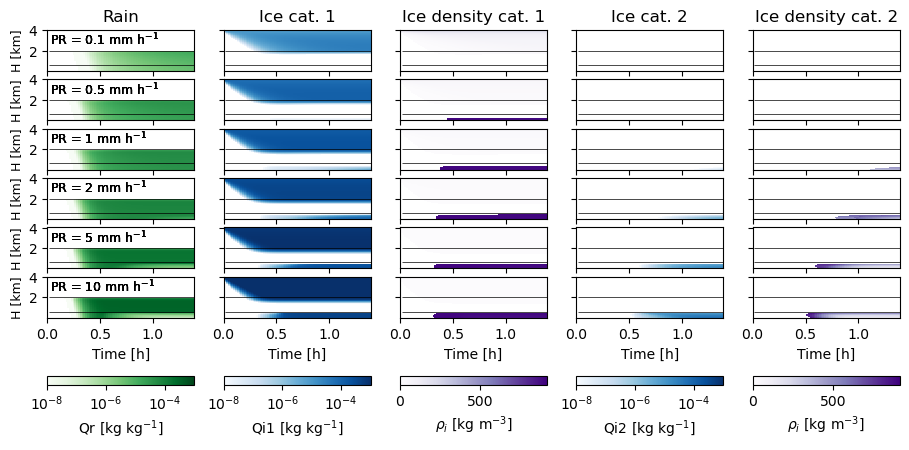

In [8]:
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

fig, ax = plt.subplots(len(ds_list_pr), 5,figsize=(11, 4))
cnt = 0

vmin = 1e-8
vmax = 1e-3
norm=matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
for j in range(len(ds_list_pr)):
    ds_all = ds_list_pr[j]

    pc0=ax[cnt,0].pcolormesh(ds_all.time/3600., ds_all.z[0,:]/1000., (ds_all.Qr).where(ds_all.Qr>0).T,cmap='Greens',norm=norm)
    ax[cnt,0].set_xlim([0,5000/3600.])  

    pc1 = ax[cnt,1].pcolormesh(ds_all.time/3600., ds_all.z[0, :]/1000., (ds_all.Qi).where(ds_all.Qi > vmin).T,cmap='Blues',norm=norm)
    ax[cnt,1].set_xlim([0,5000/3600.])

    pc2=ax[cnt,2].pcolormesh(ds_all.time/3600., ds_all.z[0,:]/1000., (ds_all.diag_rhoi).where(ds_all.Qi>vmin).T,cmap='Purples',vmin=0,vmax=915)
    ax[cnt,2].set_xlim([0,5000/3600.])    
    
    pc3=ax[cnt,3].pcolormesh(ds_all.time/3600., ds_all.z[0,:]/1000., (ds_all.Qi2).where(ds_all.Qi2>vmin).T,cmap='Blues',norm=norm)
    ax[cnt,3].set_xlim([0,5000/3600.])
    
    pc4=ax[cnt,4].pcolormesh(ds_all.time/3600., ds_all.z[0,:]/1000., (ds_all.diag_rhoi2).where(ds_all.Qi2>vmin).T,cmap='Purples',vmin=0,vmax=915)
    ax[cnt,4].set_xlim([0,5000/3600.])
    
    for i in range(5):
        ct1=ax[cnt,i].contour(ds_all.time/3600., ds_all.z[0,:]/1000., (ds_all['T']).T,colors='black',levels=[0],linewidths=0.5)

    
    cnt = cnt + 1


cax0 = inset_axes(ax[-1, 0], width="100%", height="20%", loc='lower center', borderpad=-4.8)
cax1 = inset_axes(ax[-1, 1], width="100%", height="20%", loc='lower center', borderpad=-4.8)
cax2 = inset_axes(ax[-1, 2], width="100%", height="20%", loc='lower center', borderpad=-4.8)
cax3 = inset_axes(ax[-1, 3], width="100%", height="20%", loc='lower center', borderpad=-4.8)
cax4 = inset_axes(ax[-1, 4], width="100%", height="20%", loc='lower center', borderpad=-4.8)

cbar0 = fig.colorbar(pc0, cax=cax0, orientation='horizontal')
cbar1 = fig.colorbar(pc1, cax=cax1, orientation='horizontal')
cbar2 = fig.colorbar(pc2, cax=cax2, orientation='horizontal')
cbar3 = fig.colorbar(pc3, cax=cax3, orientation='horizontal')
cbar4 = fig.colorbar(pc4, cax=cax4, orientation='horizontal')

cbar0.set_label(r'Qr [kg kg$^{-1}$]')
cbar1.set_label(r'Qi1 [kg kg$^{-1}$]')
cbar2.set_label(r'$\rho_i$ [kg m$^{-3}$]')
cbar3.set_label(r'Qi2 [kg kg$^{-1}$]')
cbar4.set_label(r'$\rho_i$ [kg m$^{-3}$]')

for cnt in range(len(ds_list_pr)):
    ax[cnt,0].set_ylabel('H [km]',fontsize=9)
    ax[cnt,0].set_xlabel('')
    ax[cnt,1].set_xlabel('')
    ax[cnt,2].set_xlabel('')

    ax[cnt,1].set_yticklabels([])
    ax[cnt,2].set_yticklabels([])
    ax[cnt,3].set_yticklabels([])
    ax[cnt,4].set_yticklabels([])

for cnt in range(len(ds_list_pr)-1):
    ax[cnt,0].set_xticklabels('')
    ax[cnt,1].set_xticklabels('')
    ax[cnt,2].set_xticklabels('')
    ax[cnt,3].set_xticklabels('')
    ax[cnt,4].set_xticklabels('')

ax[0,0].set_title('Rain')
ax[0,1].set_title('Ice cat. 1')
ax[0,2].set_title('Ice density cat. 1')
ax[0,3].set_title('Ice cat. 2')
ax[0,4].set_title('Ice density cat. 2')


for i in range(5):
    ax[len(ds_list_pr)-1,i].set_xlabel('Time [h]')

    for r, ds_all in enumerate(ds_list_pr):
        ax[r, 0].text(
            0.02, 0.96,
            f"PR = {pr_list[r]:g} mm h$^{{-1}}$",
            transform=ax[r, 0].transAxes,
            ha='left', va='top',
            fontsize=9,# fontweight='bold',
           # bbox=dict(facecolor=None, alpha=1., edgecolor='none', pad=1.5)
        )

fig.subplots_adjust(bottom=0.16)
plt.savefig('/home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/figures/figures_sensitivity_pcs.png',format='png',bbox_inches='tight',dpi=300)
          